# Week 13-2 · OTS-01 — General Trading Theory

**Instructor: Euan Sinclair** — an options trader since 1995 (PhD physics → City of London → market
maker, prop trader, hedge funds, investment banks; now runs volatility at an ETF provider). This is
the *opening* lecture of the Options module, and its whole message is deliberately provocative:

> *"There are two words in the title — **option** and **trading**. By far the most important is
> **trading**. You cannot be an options trader without first being a trader. There is nothing
> magical about options."*

So this session teaches **general trading theory**, not options mechanics. There is **no programming
in the lecture itself** — but every claim Sinclair makes is quantitative, so this notebook turns his
verbal arguments into numbers you can check. We reproduce: **expected value / edge**, why **win-rate
is not edge**, the **Sharpe-ratio luck calculations**, the **risk-premium vs inefficiency**
distinction, and why you should **never be a hero** (position sizing).

**The trading pyramid (in order of importance):**
1. **Edge** — an unfair advantage; positive expected value. *Without it nothing else matters.*
2. **Risk management** — everything that isn't edge. Keeps you in the game to reach the long run.
3. **Psychology** — smallest of the three; can't save you if you have no edge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
rng = np.random.default_rng(7)
print("ready")

ready


## 1. Edge = expected value (the loaded-coin canonical example)

**Edge** literally means a trade has **positive expected value (EV)** — the probability-weighted
average outcome:

$$\text{EV} = \sum_i p_i \cdot x_i$$

Sinclair's canonical example: a coin that comes up heads **55%** of the time. You call heads; win \$1
or lose \$1.

In [2]:
def expected_value(outcomes):
    return sum(p * x for p, x in outcomes)

coin = [(0.55, +1.0), (0.45, -1.0)]
ev = expected_value(coin)
print(f"Loaded coin (55% win): EV = 0.55*(+1) + 0.45*(-1) = {ev:+.2f}  -> POSITIVE edge")
print("Note: 10 cents is the AVERAGE. You never get 10c on a single toss (+1 or -1 only).")

Loaded coin (55% win): EV = 0.55*(+1) + 0.45*(-1) = +0.10  -> POSITIVE edge
Note: 10 cents is the AVERAGE. You never get 10c on a single toss (+1 or -1 only).


In [3]:
# Law of large numbers: the 10c edge is only realized over many trials
def simulate_coin(p_win, win, lose, n, trials=2000):
    wins = rng.random((trials, n)) < p_win
    pnl = np.where(wins, win, lose).sum(axis=1)
    return pnl

for n in (1, 10, 100, 1000):
    pnl = simulate_coin(0.55, 1, -1, n)
    print(f"n={n:>4} tosses: mean total P&L = {pnl.mean():8.2f}  "
          f"(per-toss {pnl.mean()/n:+.3f}), %profitable runs = {(pnl>0).mean()*100:5.1f}%")
print("\nEdge is a long-run average. Short runs are dominated by luck -> 'survive to the long run'.")

n=   1 tosses: mean total P&L =     0.11  (per-toss +0.113), %profitable runs =  55.6%
n=  10 tosses: mean total P&L =     0.88  (per-toss +0.088), %profitable runs =  48.9%
n= 100 tosses: mean total P&L =     9.77  (per-toss +0.098), %profitable runs =  81.3%
n=1000 tosses: mean total P&L =   100.42  (per-toss +0.100), %profitable runs = 100.0%

Edge is a long-run average. Short runs are dominated by luck -> 'survive to the long run'.


## 2. Same edge, very different risk — and why **win-rate is NOT edge**

Sinclair stresses two traps. First, **two bets can have identical EV but wildly different risk**.
Second — the one even experienced traders get wrong — **winning more often is not an edge**.

In [4]:
# Two coins with the SAME expected value but very different variance (Sinclair's example)
coin_A = [(0.55, +1.0),  (0.45, -1.0)]    # wins often, small payoff
coin_B = [(0.10, +10.0), (0.90, -1.0)]    # rarely wins, big payoff -> 0.10*10 + 0.90*(-1) = 0.10
print(f"Coin A: EV = {expected_value(coin_A):+.3f}, win-rate 55%")
print(f"Coin B: EV = {expected_value(coin_B):+.3f}, win-rate 10%")
pA = simulate_coin(0.55,  1, -1, 100)
pB = simulate_coin(0.10, 10, -1, 100)
print(f"\nOver 100 trials: A std = {pA.std():.1f}  vs  B std = {pB.std():.1f}  "
      f"-> same edge, B is ~{pB.std()/pA.std():.1f}x riskier")

Coin A: EV = +0.100, win-rate 55%
Coin B: EV = +0.100, win-rate 10%

Over 100 trials: A std = 9.8  vs  B std = 32.5  -> same edge, B is ~3.3x riskier


In [5]:
# WIN-RATE IS NOT EDGE: a die that wins 2/3 of the time but has NEGATIVE edge
# Land on 1,2,3,4 (prob 4/6) -> win $0.40 ; land on 5,6 (prob 2/6) -> lose $1
die = [(4/6, +0.40), (2/6, -1.00)]
print(f"Die: wins {4/6*100:.1f}% of the time, but EV = {expected_value(die):+.3f}  -> NEGATIVE edge")
print("Winning often != edge. Betting favourites / selling far-OTM options 'wins' often yet loses long-run.")

Die: wins 66.7% of the time, but EV = -0.067  -> NEGATIVE edge
Winning often != edge. Betting favourites / selling far-OTM options 'wins' often yet loses long-run.


**The options parallel.** Selling *very far out-of-the-money* options wins almost every time —
but that high hit-rate says nothing about edge. Selling *at-the-money* options is closer to 50/50.
In both cases the win-rate is irrelevant; only the **EV after the occasional large loss** matters.

## 3. Sampling error in finance — you measure the result exactly, not the *true edge*

In physics, "sampling error" means your instrument is imprecise. In finance it's the opposite: you
know **exactly** that you made \$30 — but you **don't know the true edge** behind it, and that edge
keeps changing. Sinclair's analogy: a batsman scores 100 in one innings (the exact result), but that
tells you little about his **true average** (Don Bradman's career average was 99.94, the next-best
ever ~60). One result is not the underlying ability.

In [6]:
# A trader with a TRUE per-trade edge of 0.10 and unit risk: what does a 30-trade sample tell us?
true_edge = 0.10
samples = simulate_coin(0.55, 1, -1, 30, trials=5000) / 30   # observed per-trade edge over 30 trades
print(f"True per-trade edge = {true_edge:+.3f}")
print(f"Observed edge over 30 trades: mean {samples.mean():+.3f}, "
      f"but ranges [{np.percentile(samples,5):+.3f}, {np.percentile(samples,95):+.3f}] (90% band)")
print("The single observed number is exact; the TRUE edge behind it is uncertain and time-varying.")

True per-trade edge = +0.100
Observed edge over 30 trades: mean +0.098, but ranges [-0.200, +0.400] (90% band)
The single observed number is exact; the TRUE edge behind it is uncertain and time-varying.


## 4. Risk = everything that isn't edge — the luck (variance) calculation

Sinclair's most concrete risk-management point: even a **good** strategy loses over short windows
purely from luck. A strategy with a **Sharpe ratio of 1.5** still has a losing **year** about **7%**
of the time. Knowing your *expected* Sharpe tells you what results to expect — so you can tell luck
apart from a broken strategy.

In [7]:
def prob_loss(sharpe_annual, horizon_years):
    # P(cumulative return < 0) over the horizon, assuming iid normal returns
    sharpe_h = sharpe_annual * np.sqrt(horizon_years)
    return norm.cdf(-sharpe_h)

print("Sharpe 1.5:")
print(f"  P(losing year)   = {prob_loss(1.5, 1)*100:5.1f}%   <- Sinclair's '7%'")
print(f"  P(losing 2 yrs)  = {prob_loss(1.5, 2)*100:5.1f}%")

print("\nSharpe 5 (HFT-like):")
print(f"  P(losing month)  = {prob_loss(5.0, 1/12)*100:5.2f}%   (Sinclair eyeballed '~2%'; actual below)")
print(f"  P(losing year)   = {prob_loss(5.0, 1)*100:.5f}%")
print("\nLesson: a Sharpe-5 shop losing for a MONTH is suspicious (likely overfit) -- knowing your")
print("expected Sharpe lets you separate normal variance from a real problem.")

Sharpe 1.5:
  P(losing year)   =   6.7%   <- Sinclair's '7%'
  P(losing 2 yrs)  =   1.7%

Sharpe 5 (HFT-like):
  P(losing month)  =  7.45%   (Sinclair eyeballed '~2%'; actual below)
  P(losing year)   = 0.00003%

Lesson: a Sharpe-5 shop losing for a MONTH is suspicious (likely overfit) -- knowing your
expected Sharpe lets you separate normal variance from a real problem.


**Other risks Sinclair lists** (all "everything that isn't edge"):
- **Model risk** — maybe the edge was never there, or has decayed. Statistics of your *results* are a
  terrible early-warning system; you need a *reason* the edge exists, and you stop when the reason
  goes away (e.g. end-of-month stock drift from US payroll/retirement inflows).
- **Things you don't predict but others do** — for an options trader the one prediction is
  **volatility**; stock moves, FX, rates, dividends are *risk* → isolate the edge, hedge the rest.
- **Meta-risks** — outside the game: 9/11 closed the market, wars, inflation, and above all
  **fraud/theft** (Sumitomo, Kerviel, Leeson, Madoff, FTX). Leeson was *both* trader and risk
  manager — you need an **independent** risk layer. Don't put all eggs in one basket.
- **Black swans** — *unimaginable* events (an index/ETF restructuring changing dividend risk), not
  merely big ones. You can't predict them, but you **hedge the consequences, not the probabilities**
  — while not over-hedging away your whole edge.

## 5. EMH and the two kinds of edge

A market is **efficient** with respect to some information if you **can't profit** from it. EMH isn't
literally true, but it's a very good approximation — "the earth is a sphere" vs the older "flat
earth". You make money in the small **exceptions** (the pilot flies a great circle but still avoids
the mountains). EMH even tells you **where to look**: constrained markets (early crypto), information
asymmetries (FX front-running, commodities), and participants with **different goals**.

Two kinds of edge come out of this:

In [8]:
# (A) INEFFICIENCY: a risk-free arbitrage (buy gold in London, sell in NY). Transient -> trade big.
london, ny = 2000.00, 2002.50
arb = ny - london
print(f"(A) INEFFICIENCY (arbitrage): buy London {london}, sell NY {ny} -> {arb:+.2f}/oz risk-free")
print("    Transient (others notice & close it). When found, trade as BIG as you practically can.\n")

# (B) RISK PREMIUM: someone pays you to take a risk they don't want (insurance / selling options).
# Model: sell an option for premium; usually keep it, occasionally pay a large claim.
premium   = 1.00          # collected every time
p_blowup  = 0.03          # rare large loss
loss_size = 20.0          # size of the rare loss
ev_short = (1-p_blowup)*premium + p_blowup*(premium - loss_size)
print(f"(B) RISK PREMIUM (sell options/insurance): premium {premium}, "
      f"P(blowup)={p_blowup}, loss {loss_size}")
print(f"    EV per trade = {ev_short:+.3f}  -> POSITIVE, but fat-tailed.")
print("    Persistent (insurance demand never goes away) -> can be the BASIS of a business.")
print("    Options 'overpriced' is a 150-year-old effect (noted in an 1905 book on 1890s trading).")

(A) INEFFICIENCY (arbitrage): buy London 2000.0, sell NY 2002.5 -> +2.50/oz risk-free
    Transient (others notice & close it). When found, trade as BIG as you practically can.

(B) RISK PREMIUM (sell options/insurance): premium 1.0, P(blowup)=0.03, loss 20.0
    EV per trade = +0.400  -> POSITIVE, but fat-tailed.
    Persistent (insurance demand never goes away) -> can be the BASIS of a business.
    Options 'overpriced' is a 150-year-old effect (noted in an 1905 book on 1890s trading).


In [9]:
# Why you must hedge the CONSEQUENCE, not the probability: the short-premium P&L distribution
n = 10_000
claims = rng.random(n) < p_blowup
pnl = np.where(claims, premium - loss_size, premium)
print(f"Short-premium strategy over {n:,} trades:")
print(f"  mean P&L/trade = {pnl.mean():+.3f} (matches EV {ev_short:+.3f})")
print(f"  %profitable trades = {(pnl>0).mean()*100:.1f}%  <- looks great...")
print(f"  worst trade = {pnl.min():+.1f}, 1st percentile = {np.percentile(pnl,1):+.1f}")
print("  The edge is real, but un-hedged tails can ruin you. Hedge the consequence.")

Short-premium strategy over 10,000 trades:
  mean P&L/trade = +0.390 (matches EV +0.400)
  %profitable trades = 97.0%  <- looks great...
  worst trade = -19.0, 1st percentile = -19.0
  The edge is real, but un-hedged tails can ruin you. Hedge the consequence.


## 6. Don't be a hero — position sizing turns edge into survival

Even with a real edge, betting too big destroys you. Sinclair: *"betting everything you own on a 55%
coin... you have the edge, but that's still a dumb thing to do."* The growth-optimal bet on a 55/45
coin is the **Kelly fraction** $f^* = p - q = 0.10$ — tiny. Below we race **all-in**, **full-Kelly**,
and **half-Kelly** on the very same edge.

In [10]:
def grow(fraction, p_win=0.55, n=300, paths=4000):
    wins = rng.random((paths, n)) < p_win
    growth = np.where(wins, 1 + fraction, 1 - fraction)
    wealth = growth.prod(axis=1)         # start at 1.0
    return wealth

for name, f in [("all-in (f=1.0)", 1.0), ("full-Kelly (f=0.10)", 0.10), ("half-Kelly (f=0.05)", 0.05)]:
    w = grow(f)
    print(f"{name:22} median wealth x{np.median(w):8.3f}  "
          f"P(ruin <1% start) = {(w < 0.01).mean()*100:5.1f}%")
print("\nAll-in has the edge yet almost surely goes broke. Sensible sizing = survive to the long run.")

all-in (f=1.0)         median wealth x   0.000  P(ruin <1% start) = 100.0%
full-Kelly (f=0.10)    median wealth x   4.493  P(ruin <1% start) =   0.0%
half-Kelly (f=0.05)    median wealth x   3.083  P(ruin <1% start) =   0.0%

All-in has the edge yet almost surely goes broke. Sensible sizing = survive to the long run.


## 7. Summary chart — edge, the luck of Sharpe, and why size matters

saved chart_1_edge.png


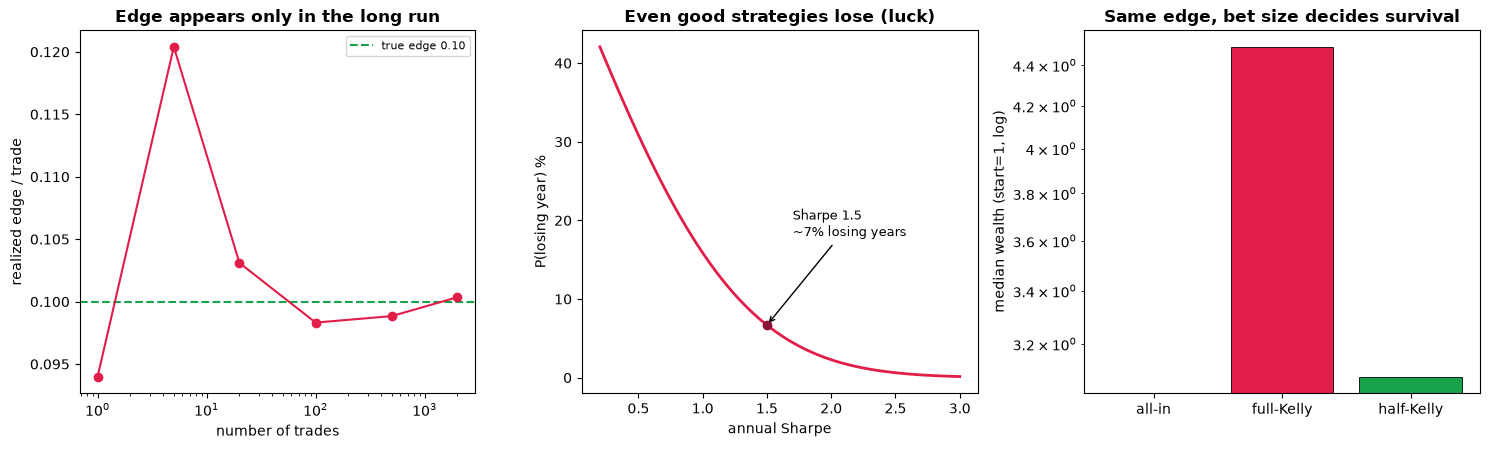

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
ROSE="#e11d48"; ROSE2="#fb7185"; GREEN="#16a34a"; GREY="#9ca3af"; DARK="#881337"

# (1) EV converges only in the long run
ns = [1, 5, 20, 100, 500, 2000]
per_toss = [simulate_coin(0.55,1,-1,n).mean()/n for n in ns]
ax[0].axhline(0.10, color=GREEN, ls="--", lw=1.5, label="true edge 0.10")
ax[0].plot(ns, per_toss, "o-", color=ROSE)
ax[0].set_xscale("log"); ax[0].set_title("Edge appears only in the long run", fontweight="bold")
ax[0].set_xlabel("number of trades"); ax[0].set_ylabel("realized edge / trade"); ax[0].legend(fontsize=8)

# (2) Probability of a losing year vs Sharpe
sharpes = np.linspace(0.2, 3, 60)
ax[1].plot(sharpes, [prob_loss(s,1)*100 for s in sharpes], color=ROSE, lw=2)
ax[1].scatter([1.5],[prob_loss(1.5,1)*100], color=DARK, zorder=5)
ax[1].annotate("Sharpe 1.5\n~7% losing years", (1.5, prob_loss(1.5,1)*100),
               xytext=(1.7,18), fontsize=9, arrowprops=dict(arrowstyle="->"))
ax[1].set_title("Even good strategies lose (luck)", fontweight="bold")
ax[1].set_xlabel("annual Sharpe"); ax[1].set_ylabel("P(losing year) %")

# (3) Wealth under different bet sizes (same edge)
for name, f, c in [("all-in", 1.0, GREY), ("full-Kelly", 0.10, ROSE), ("half-Kelly", 0.05, GREEN)]:
    med = np.median([grow(f) for _ in range(1)][0])
    ax[2].bar(name, med, color=c, edgecolor="black", lw=0.6)
ax[2].set_yscale("log"); ax[2].set_title("Same edge, bet size decides survival", fontweight="bold")
ax[2].set_ylabel("median wealth (start=1, log)")

plt.tight_layout(); plt.savefig("chart_1_edge.png", dpi=115, bbox_inches="tight")
print("saved chart_1_edge.png")

## 8. The one-paragraph version

You are a **trader first** and an options trader second — there is nothing magical about any
instrument. Trading is the **trading pyramid**: **edge** (the only thing that makes money),
**risk management** (everything that isn't edge; it keeps you alive to reach the long run), and a
sliver of **psychology**. **Edge = positive expected value**, the probability-weighted average — a
55% coin has EV +10¢ realized only over *many* trades, which is why you must *survive to the long
run* and never *be a hero* with size. **Win-rate is not edge** (a die that wins ⅔ of the time can
still lose money; so can selling far-OTM options). **Risk is everything else** — model decay,
variance/luck (a Sharpe-1.5 strategy loses ~7% of years), unpredicted factors, meta-risks like
**fraud** (Leeson was trader *and* risk manager), and **black swans** (hedge the *consequences*, not
the probabilities). The **EMH** is a great approximation; you live in its small exceptions, which
come in two flavours: **inefficiencies** (arbitrage — transient, trade big) and **risk premia**
(someone pays you to take a risk they dislike — insurance, *selling options* — persistent, the basis
of a career). Above all: **find the observation first, then quantify it simply** — the magic is in
the observation, never in the method.